Using device: mps
class: 10 (['blues', 'classical', 'country', 'disco', 'hiphop', 'jazz', 'metal', 'pop', 'reggae', 'rock'])


Epoch [1/30] | Loss: 2.4066 | Train Acc: 0.1952 | Test Acc: 0.1400


Epoch [2/30] | Loss: 1.8203 | Train Acc: 0.3529 | Test Acc: 0.5200


Epoch [3/30] | Loss: 1.5858 | Train Acc: 0.4305 | Test Acc: 0.5250


Epoch [4/30] | Loss: 1.4127 | Train Acc: 0.4844 | Test Acc: 0.5300


...

Epoch [26/30] | Loss: 0.1290 | Train Acc: 0.9775 | Test Acc: 0.7500


Epoch [27/30] | Loss: 0.1082 | Train Acc: 0.9887 | Test Acc: 0.7350


Epoch [28/30] | Loss: 0.1032 | Train Acc: 0.9887 | Test Acc: 0.7150


Epoch [29/30] | Loss: 0.0992 | Train Acc: 0.9850 | Test Acc: 0.7450


Epoch [30/30] | Loss: 0.0910 | Train Acc: 0.9850 | Test Acc: 0.7650
Done！
final accuracy: 76.5000%
Image Saved


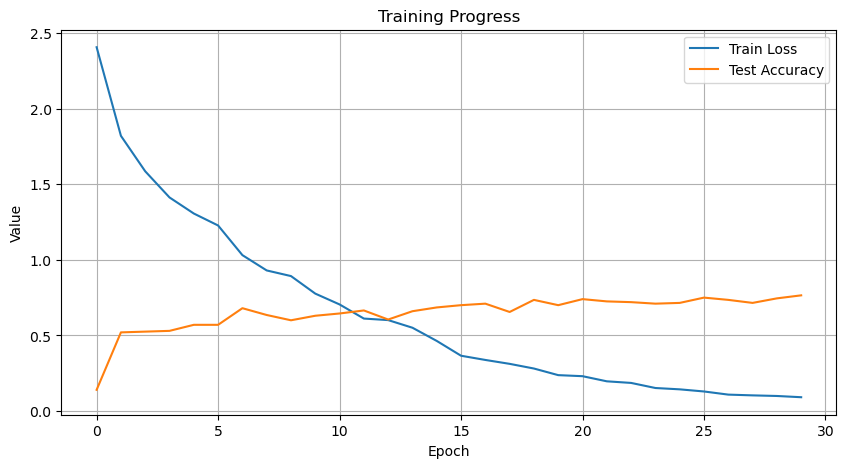

In [ ]:
# Needed Imports
import torch
import torch.nn as nn
import numpy as np
import torch.optim as optim
import torchvision
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split
import matplotlib.pyplot as plt
from tqdm import tqdm
from sklearn.metrics import classification_report

# GLobal Vars needed
DATA_DIR = "../image_data/Data/images_original"
BATCH_SIZE = 32
IMG_SIZE = 128
LEARNING_RATE = 0.0001
EPOCHS = 30

# Deciding where to train this data
if torch.cuda.is_available():
    DEVICE = 'cuda'
elif torch.backends.mps.is_available():
    DEVICE = 'mps'
else:
    DEVICE = 'cpu'
print(f"Using device: {DEVICE}")

# Preprocessing pipeline for train images
# Transformin / normalizing train image data
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])
# Preprocessing pipeline for test images
# Transforming / normalizing test image data
test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

try:
    full_dataset = datasets.ImageFolder(root=DATA_DIR, transform=train_transform)
except Exception as e:
    exit()

# Extractign class names
class_names = full_dataset.classes
num_classes = len(class_names)
print(f"class: {num_classes} ({class_names})")


# Actually splitting test / train data
generator = torch.Generator().manual_seed(42)
train_size = int(0.8 * len(full_dataset))
test_size = len(full_dataset) - train_size
train_data, test_data = random_split(full_dataset, [train_size, test_size], generator=generator)

train_loader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_data, batch_size=BATCH_SIZE, shuffle=False)

# --- 3. モデル定義 ---
# Initializing CNN architecture 
class CustomCNN(nn.Module):
    def __init__(self, num_classes):
        super(CustomCNN, self).__init__()
        self.conv1 = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )
        self.conv2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )
        self.conv3 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )
        self.conv4 = nn.Sequential(
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )
        
        self.fc_input_size = 256 * 8 * 8
        self.dropout = nn.Dropout(0.6)
        self.fc = nn.Linear(self.fc_input_size, num_classes)

    # Forward pass pipeline
    def forward(self, x):
        x = self.conv1(x)
        x = self.conv2(x)
        x = self.conv3(x)
        x = self.conv4(x)
        x = x.view(x.size(0), -1)
        x = self.dropout(x)
        x = self.fc(x)
        return x

# Actually initializing Model to use
model = CustomCNN(num_classes).to(DEVICE)

# Telling model loss function and optimization function
# using Log loss, Adam optimizer, weight decay for regularization
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-5)

train_losses = []
test_accuracies = []

# Train loop
for epoch in range(EPOCHS):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    progress_bar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS}", leave=False)
    
    for images, labels in progress_bar:
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        
        progress_bar.set_postfix({'loss': loss.item()})
    
    epoch_loss = running_loss / len(train_loader)
    epoch_acc = correct / total
    train_losses.append(epoch_loss)
    
    # Evaluating Model
    model.eval()
    test_correct = 0
    test_total = 0
    all_labels = []
    all_predicted = []
    # Test loop (batches)
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            test_total += labels.size(0)
            test_correct += (predicted == labels).sum().item()
            all_labels.extend(labels.cpu().numpy())
            all_predicted.extend(predicted.cpu().numpy())
    
    test_acc = test_correct / test_total
    test_accuracies.append(test_acc)
    all_labels = np.array(all_labels)
    all_predicted = np.array(all_predicted)

    print(f"Epoch [{epoch+1}/{EPOCHS}] | Loss: {epoch_loss:.4f} | Train Acc: {epoch_acc:.4f} | Test Acc: {test_acc:.4f}")

print("Done！")
print(f"final accuracy: {test_accuracies[-1]*100:.4f}%")

# Plotting loss and accuracy
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Train Loss')
plt.plot(test_accuracies, label='Test Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Value')
plt.title('Training Progress')
plt.legend()
plt.grid()
plt.savefig('training_result_final_cnn.png')
print("Image Saved")

In [2]:
# Further analysis
print("Analysis\n")
print(classification_report(all_labels, all_predicted, target_names=class_names, digits=4))

Analysis

              precision    recall  f1-score   support

       blues     0.6667    0.7000    0.6829        20
   classical     0.8235    0.8750    0.8485        16
     country     0.7778    0.7000    0.7368        20
       disco     0.7619    0.6400    0.6957        25
      hiphop     0.8421    0.8421    0.8421        19
        jazz     0.8636    0.8636    0.8636        22
       metal     0.9412    0.8889    0.9143        18
         pop     0.7826    0.7826    0.7826        23
      reggae     0.7143    0.7143    0.7143        21
        rock     0.5238    0.6875    0.5946        16

    accuracy                         0.7650       200
   macro avg     0.7698    0.7694    0.7675       200
weighted avg     0.7722    0.7650    0.7667       200

